Manutencao preditiva de trocas de oleo
Esse notebook faz a limpeza dos dados, mostra os graficos de analise e testa uns modelos simples de previsao.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Carregando os dados

In [34]:
df = pd.read_csv('dataset.csv', parse_dates=['Data'], index_col='Data')
df = df.sort_index()
df.head()

,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


Preenchendo os dias que faltam no dataset e os valores em branco

In [35]:
dias = pd.date_range(df.index.min(), df.index.max(), freq='D')
df = df.reindex(dias)
df.index.name = 'Data'

df['Trocas_Oleo'] = pd.to_numeric(df['Trocas_Oleo'], errors='coerce')
df['Trocas_Oleo'] = df['Trocas_Oleo'].interpolate().ffill().bfill().round()

df['Manutencao_Motor'] = pd.to_numeric(df['Manutencao_Motor'], errors='coerce')
df['Manutencao_Motor'] = df['Manutencao_Motor'].interpolate().ffill().bfill()

df.isna().sum()

,0
Trocas_Oleo,0
Manutencao_Motor,0


Tirando os outliers, tipo aquele dia com 500 trocas por erro de digitacao do mecanico. Usamos media + 3 desvios padrao como limite normal e cortamos quem passar disso.

In [36]:
media = df['Trocas_Oleo'].mean()
desvio = df['Trocas_Oleo'].std()
limite = round(media + 3 * desvio)
print('limite considerado normal:', limite)

df['Trocas_Oleo'] = df['Trocas_Oleo'].clip(upper=limite)

limite considerado normal: 61


Grafico da serie completa

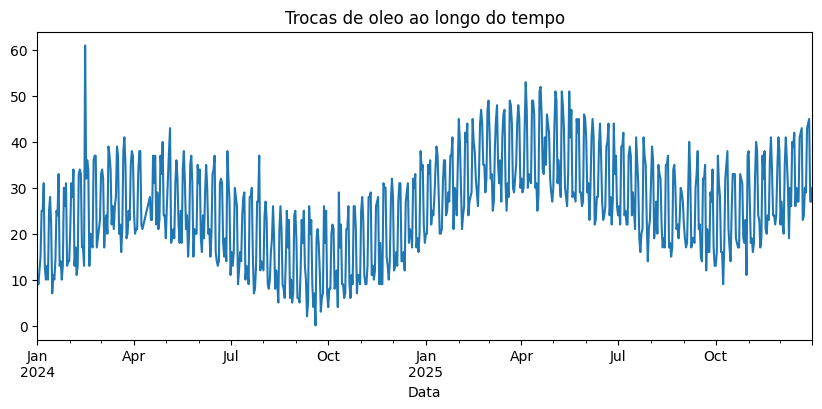

In [37]:
df['Trocas_Oleo'].plot(figsize=(10, 4), title='Trocas de oleo ao longo do tempo')
plt.show()

Separando a serie em tendencia, sazonalidade e ruido

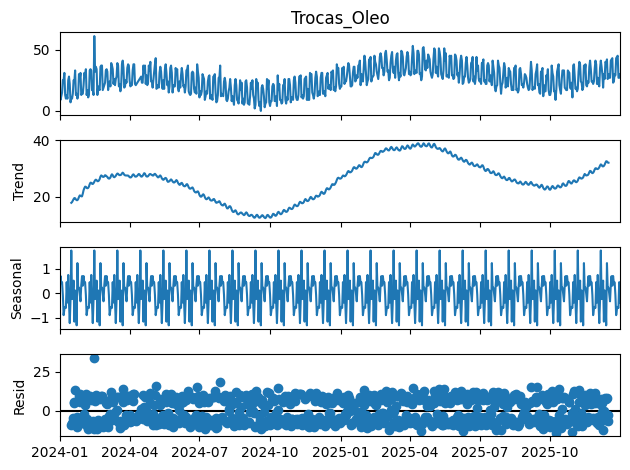

In [38]:
resultado = seasonal_decompose(df['Trocas_Oleo'], model='additive', period=30)
resultado.plot()
plt.show()

Modelo naive: a previsao de amanha e igual ao valor de hoje

In [39]:
df['previsao_naive'] = df['Trocas_Oleo'].shift(1)

Modelo de media movel: a previsao e a media dos ultimos 7 e dos ultimos 30 dias

In [40]:
df['media_movel_7'] = df['Trocas_Oleo'].shift(1).rolling(7).mean()
df['media_movel_30'] = df['Trocas_Oleo'].shift(1).rolling(30).mean()

Comparando o valor real com as previsoes dos modelos baseline

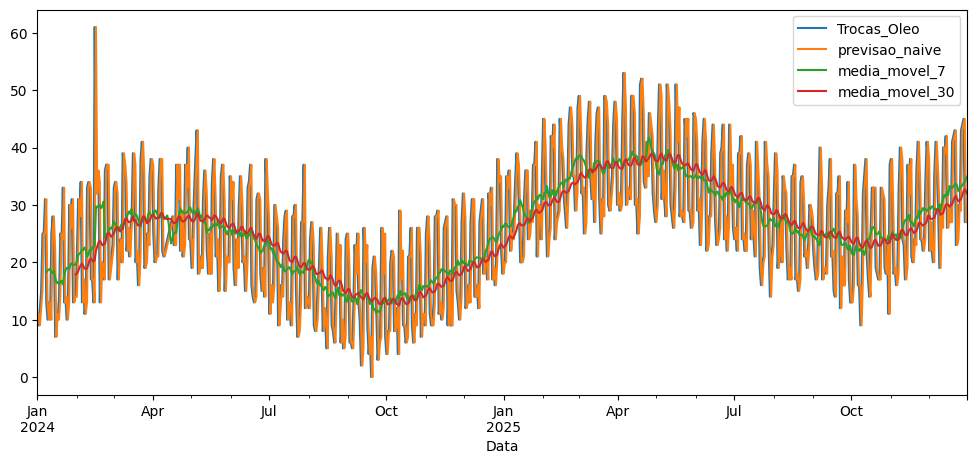

In [41]:
df[['Trocas_Oleo', 'previsao_naive', 'media_movel_7', 'media_movel_30']].plot(figsize=(12, 5))
plt.show()

Modelo preditivo usando naive bayes, com Manutencao_Motor como variavel de entrada

In [42]:
df_avaliacao = df.dropna(subset=['previsao_naive'])

# Separando 80% treino e 20% teste
n_teste = int(len(df_avaliacao) * 0.2)
df_teste_base = df_avaliacao.iloc[-n_teste:]

y_real_teste = df_teste_base['Trocas_Oleo']
y_previsto_naive = df_teste_base['previsao_naive']

mae_naive = mean_absolute_error(y_real_teste, y_previsto_naive)
rmse_naive = mean_squared_error(y_real_teste, y_previsto_naive)

print(f"--- Métricas do Modelo Naive no Teste ---")
print(f"MAE: {mae_naive:.2f} trocas")
print(f"RMSE: {rmse_naive:.2f} trocas")

--- Métricas do Modelo Naive no Teste ---
MAE: 6.48 trocas
RMSE: 79.36 trocas
